<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Game_ClassificationCNNV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3 Proyecto Mineria de datos

In [1]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
from torchvision import datasets, models, transforms
import time
import copy

import json
import ast

seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


# Cargar datos y descargar imagenes utilizadas

In [2]:
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam.csv'
#dfdata = pd.read_csv(url)
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_description_data.csv.zip'
#df_descriptions = pd.read_csv(url)
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_media_data.csv.zip'
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/SteamSpy_Filt_AllData.zip'
dfmedia = pd.read_csv(url)

In [3]:
dfmedia

,index,appid,name,owners,screenshots,priceclp
0,1,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.0
1,2,7800,Stubbs the Zombie in Rebel Without a Pulse,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",10500.0
2,4,10270,Disciples III: Reincarnation,100000-200000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2875.0
3,6,11550,Second Sight,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",5500.0
4,7,12210,Grand Theft Auto IV: The Complete Edition,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14990.0
...,...,...,...,...,...,...
21215,26497,2559280,Drift Cars Zombie Crusher,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",434.0
21216,26498,2559980,I commissioned some ladybugs 2,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2040.0
21217,26499,2561180,Rescue Team: Mineral of Miracles,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3570.0
21218,26500,2562650,Agriculture Tractor Sim,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",871.0


In [4]:
#dfdata.groupby('owners').count().loc[:,'name'].sort_values().plot.bar()
#ELIMINAR LOS DE CLASE entre 100000 y 200000

dfmedia = dfmedia[~ dfmedia.owners.isin(['100000-200000']) ]
dfmedia = dfmedia.reset_index(level=0,drop=True)
dfmedia

,index,appid,name,owners,screenshots,priceclp
0,1,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.0
1,2,7800,Stubbs the Zombie in Rebel Without a Pulse,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",10500.0
2,6,11550,Second Sight,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",5500.0
3,7,12210,Grand Theft Auto IV: The Complete Edition,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14990.0
4,8,16900,GROUND BRANCH,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",15500.0
...,...,...,...,...,...,...
20106,26497,2559280,Drift Cars Zombie Crusher,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",434.0
20107,26498,2559980,I commissioned some ladybugs 2,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2040.0
20108,26499,2561180,Rescue Team: Mineral of Miracles,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3570.0
20109,26500,2562650,Agriculture Tractor Sim,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",871.0


In [5]:
def class_owners(strowners):
  own_int = int(strowners.split('-')[0])
  if own_int > 100000:
    return 'Hsell'
  else:
    return 'Lsell'
class_owners(dfmedia.owners[2])

'Lsell'

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
import os
#os.listdir('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes')[1:10]
Image.open('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/add1046110.png')

<Axes: xlabel='owners_label'>

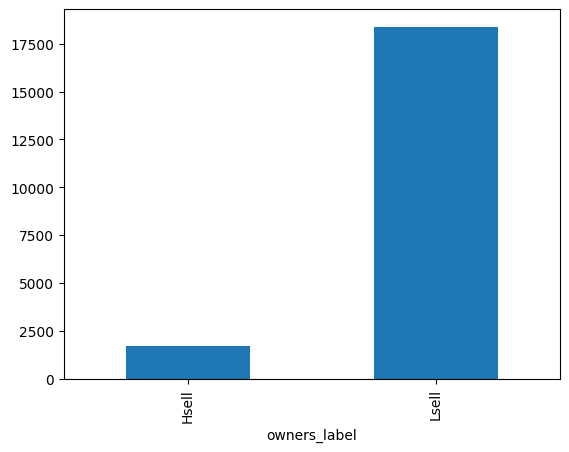

In [10]:
dfmedia['owners_label'] = [ class_owners(i) for i in dfmedia.owners ]
dfmedia.groupby('owners_label').count().loc[:,'name'].plot.bar()

Seleccionamos un sample de 500 por cada clase

In [15]:
Nsample  = 1000
labels   = ['Hsell','Lsell']
list_ids = [ random.sample(list(dfmedia.index[dfmedia.owners_label.isin([i])]),k=Nsample) for i in labels ]
dfsample = dfmedia.loc[ sum(list_ids,[]) , ['appid','name','owners','owners_label','priceclp','screenshots'] ]
dfsample

,appid,name,owners,owners_label,priceclp,screenshots
7950,1088850,Marvel's Guardians of the Galaxy,500000-1000000,Hsell,39999.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
25,65740,Carrier Command: Gaea Mission,200000-500000,Hsell,19000.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
2200,485980,Syrian Warfare,200000-500000,Hsell,1708.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
591,302080,Bus Driver,200000-500000,Hsell,2790.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
117,218740,Pid,500000-1000000,Hsell,10500.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
...,...,...,...,...,...,...
13986,1668990,Our Mountain,0-20000,Lsell,1900.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
19965,2503600,the ISLE survival,0-20000,Lsell,6299.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
10763,1331510,Battle Talent,0-20000,Lsell,10500.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
10470,1301310,Gems of Fate: the Charmed King,0-20000,Lsell,3300.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."


In [ ]:
Image.open('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/add'+str(dfsample.appid.iloc[0])+'.png')

In [ ]:
#list_img = []
#for i in dfsample.appid:
#  #screenshots  = df_media['screenshots'][df_media.steam_appid.isin([i])]
#  screenshots  = dfsample['screenshots'][dfsample.appid.isin([i])]
#  screenshots2 = screenshots.iloc[0][1:-1]
#  screenshots3 = screenshots2.split('},')
#  screen_ds = [ast.literal_eval(idict+'}') if idict[-1] != '}' else ast.literal_eval(idict) for idict in screenshots3 ]

#  aditional_image = random.sample(screen_ds,1)
#  !wget -O 'add.png' {aditional_image[0]['path_full']}
#  !wget https://cdn.cloudflare.steamstatic.com/steam/apps/{i}/header.jpg
#  add_im = Image.open('add.png')
#  list_img.append( [ Image.open('header.jpg') ,copy.deepcopy(add_im)] )
#  !rm header.jpg
#  #!rm add.png

#list_img[20]

In [ ]:
list_img[300][0]
list_img0 = [i[1] for i in list_img]

# 1 Definicion de clases y transformaciones


In [ ]:
import torchvision
class GamesDataset(torch.utils.data.Dataset):
  def __init__(self,root , appids, prices, labels, transform):
    self.transform = transform
    self.root = root
    self.class2idx = dict()
    self.class2idx['Lsell'] = 0
    self.class2idx['Hsell'] = 1
    self.classes = ['Lsell','Hsell']
    self.labels = labels

    self.header_images = []
    self.add_images  = []

    for id_image in appids:
      self.header_images.append(self.root + 'header'  + str(id_image) +'.jpg')
      self.add_images.append(self.root + 'add'  + str(id_image) +'.png')

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    header = Image.open( self.header_images[idx] ).convert('RGB')
    add = Image.open( self.header_images[idx] ).convert('RGB')
    label = self.class2idx[self.labels[idx]]

    if self.transform:
      header = self.transform(header)
      add    = self.transform(add)

    return image, label

In [ ]:
transforms = torchvision.transforms.Compose([torchvision.transforms.Resize(100),
                                             torchvision.transforms.CenterCrop(224),
                                             torchvision.transforms.ToTensor() ] )
#torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
#list_img = [i[1] for i in list_img]

Split dataset en train, validation y test

In [ ]:
from sklearn.model_selection import train_test_split
ylabel = list(dfsample['owners_label'])
X_train, X_test, Y_train, Y_test = train_test_split(list_img0, ylabel, test_size = 0.1, stratify = ylabel , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/90, stratify= Y_train, random_state=seed)

appid                                                     1125340
name                                                Tales of Lazo
owners                                                    0-20000
owners_label                                                Lsell
priceclp                                                   2400.0
screenshots     [{'id': 0, 'path_thumbnail': 'https://cdn.akam...
Name: 9217, dtype: object
Lsell


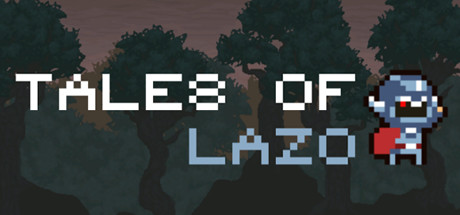

In [ ]:
ipos = 666
print(dfsample.iloc[ipos])
print(ylabel[ipos])
list_img[ipos][0]

In [ ]:
# crear Games datasets
train_dataset = GamesDataset(dataX = X_train, dataY = Y_train , transform = transforms)
valid_dataset = GamesDataset(dataX = X_val, dataY = Y_val , transform = transforms)
test_dataset  = GamesDataset(dataX = X_test, dataY = Y_test , transform = transforms)
# dataloaders
batch_size = 50

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_dataset, shuffle=True, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, shuffle=False, batch_size=1)

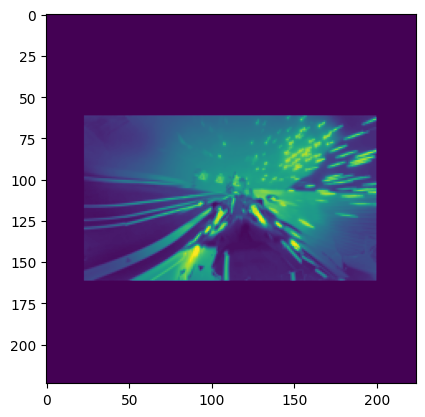

In [ ]:
import matplotlib.pyplot as plt
for test_images, test_labels in test_loader:
    sample_image = test_images[0]    # Reshape them according to your needs.
    sample_label = test_labels[0]

sample_image.shape
plt.imshow(sample_image.to('cpu').numpy()[2,:,:])

In [ ]:
# Chequear si tenemos GPU
train_on_gpu=torch.cuda.is_available()
if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# 3. CNN neural model

Basic convolution

In [ ]:
class BasicConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs: Any) -> None:
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001)

    def forward(self, x: Tensor) -> Tensor:
        x = self.conv(x)
        x = self.bn(x)
        return F.relu(x, inplace=True)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

num_epochs = 20
#batch_size_train = 64
#batch_size_test = 1000
momentum = 0.9
log_interval = 100
learning_rate=0.01

class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    #define first block for image 1
    self.conv1 = nn.Conv2d( 3, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3)


    #define second block for image 2
    self.conv1 = nn.Conv2d( 3, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3)

    #define FCL for price



    # Final FCL
    self.fc1 = nn.Linear( 54*54*64, 256) #62*62*64
    self.fc2 = nn.Linear(256,2)
  def forward(self, x):
    #define complete pipeline
    x = F.relu(F.max_pool2d(self.conv1(x), 2)) # 224x224x16 -> MaxPooling: 112x112x16  | 64x64x16 -> MaxPooling: 32x32x16
    x = F.relu(F.max_pool2d(self.conv2(x), 2)) # 112x112x32 -> MaxPooling: 56x56x32    | 32x32x32 -> MaxPooling: 16x16x32
    x = F.relu(self.conv3(x)) # 54x54x64                                               | 14x14x64
    x = x.view(-1, 54*54*64 ) # 56*56*64 )
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return F.log_softmax(x)


network = Net()
optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum)

In [ ]:
import torchsummary as ts
print(network)
ts.summary(network.to(device), (3, 224, 224), device='cuda') #-1 representa el tamaño de batch

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=186624, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
            Conv2d-2         [-1, 32, 112, 112]           4,640
            Conv2d-3           [-1, 64, 54, 54]          18,496
            Linear-4                  [-1, 256]      47,776,000
            Linear-5                    [-1, 2]             514
Total params: 47,800,098
Trainable params: 47,800,098
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 10.61
P

<ipython-input-107-5cb8ec72d414>:28: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


In [ ]:
train_losses = []
train_counter = []
test_losses = []
validation_losses = []

test_counter = [i*len(train_loader.dataset) for i in range(num_epochs+1)]

#Function to train one epoch
def train(network, optimizer,  epoch):
  network.train() #Modo entrenamiento
  for batchId, (data, target) in enumerate(train_loader): #Iterate over batches
    data = data.to(device)
    target = target.to(device)

    #Feedforward pass
    optimizer.zero_grad()
    output = network(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()

    if batchId % log_interval == 0:
      print('Train epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(epoch, batchId*len(data), len(train_loader.dataset), 100.*batchId/len(train_loader), loss.item()))
      train_losses.append(loss.item())
      train_counter.append((batchId*64) + ((epoch-1)*len(train_loader.dataset)))
      torch.save(network.state_dict(),'model.pth')
      torch.save(optimizer.state_dict(), 'optimizer.pth')

#Validation
def validation(network):
  network.eval() #Test mode
  validation_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in valid_loader:
      data = data.to(device)
      target = target.to(device)
      output = network(data)
      validation_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  length = len(valid_loader.dataset)
  validation_loss /= length
  validation_losses.append(validation_loss)
  print('\nValidation set: Avg. Loss: {:.4f}, Accuracy: {}/{} ({:.0f}%), Error: {:.3f}% \n'.format(validation_loss, correct, len(valid_loader.dataset), 100.*correct/len(valid_loader.dataset), 100.*(length-correct)/length))


#Testing
def test(network):
  network.eval() #Test mode
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      data = data.to(device)
      target = target.to(device)
      output = network(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  length = len(test_loader.dataset)
  test_loss /= length
  test_losses.append(test_loss)
  print('\nTest set: Avg. Loss: {:.4f}, Accuracy: {}/{} ({:.0f}%), Error: {:.3f}% \n'.format(test_loss, correct, len(test_loader.dataset), 100.*correct/len(test_loader.dataset), 100.*(length-correct)/length))

In [ ]:
test(network)
for epoch in range(1, num_epochs + 1):
  train(network, optimizer, epoch)
  validation(network)
  test(network)


<ipython-input-107-5cb8ec72d414>:28: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)
/usr/local/lib/python3.10/dist-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Avg. Loss: 0.6935, Accuracy: 50/100 (50%), Error: 50.000% 

Train epoch: 1 [0/800 (0%)]	Loss: 0.692553

Validation set: Avg. Loss: 0.6933, Accuracy: 50/100 (50%), Error: 50.000% 


Test set: Avg. Loss: 0.6934, Accuracy: 50/100 (50%), Error: 50.000% 

Train epoch: 2 [0/800 (0%)]	Loss: 0.694172

Validation set: Avg. Loss: 0.6934, Accuracy: 50/100 (50%), Error: 50.000% 


Test set: Avg. Loss: 0.6934, Accuracy: 50/100 (50%), Error: 50.000% 

Train epoch: 3 [0/800 (0%)]	Loss: 0.695383

Validation set: Avg. Loss: 0.6933, Accuracy: 50/100 (50%), Error: 50.000% 


Test set: Avg. Loss: 0.6933, Accuracy: 50/100 (50%), Error: 50.000% 

Train epoch: 4 [0/800 (0%)]	Loss: 0.693311

Validation set: Avg. Loss: 0.6931, Accuracy: 50/100 (50%), Error: 50.000% 


Test set: Avg. Loss: 0.6932, Accuracy: 52/100 (52%), Error: 48.000% 

Train epoch: 5 [0/800 (0%)]	Loss: 0.692977

Validation set: Avg. Loss: 0.6931, Accuracy: 50/100 (50%), Error: 50.000% 


Test set: Avg. Loss: 0.6932, Accuracy: 50/10

--------------------------------------------------------------------------------------------

In [ ]:
def train_model(model,criterio,optimizer,scheduler,train_loader,train_data,val_loader,val_data,num_epochs = 100):
  since = time.time()
  best_model_wts = copy.deepcopy(model.state_dict())
  best_acc = 0.0
  best_acc_train = 0.0
  best_acc_val = 0.0
  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    #print('-' * 10)
    #Train model
    scheduler.step()
    model.train()
    running_loss = 0.0
    running_corrects = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss /len(train_data)
    epoch_acc_train = running_corrects.double() / len(train_data)
    print('Train Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc_train))
    #Validation
    model.eval()
    running_loss = 0.0
    running_corrects = 0.0
    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
      running_loss += loss.item() * inputs.size(0)
      running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss /len(val_data)
    epoch_acc = running_corrects.double() / len(val_data)
    print('Val Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))
    if epoch_acc > best_acc:
        best_acc_train = epoch_acc_train
        best_acc = epoch_acc
        best_acc_val = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())
    if float(epoch_acc_train) - float(epoch_acc)  > 0.3:
      print('early stopping at epoch ',epoch)
      print(epoch_acc_train)
      print(epoch_acc)
      break
  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
  print('Best val accucary: {:.4f}'.format(best_acc))
  print('Best train accucary: {:.4f}'.format(best_acc_train))
  print('--------------------------------------')
  print('--------------------------------------')
  print('--------------------------------------')
  model.load_state_dict(best_model_wts)
  return model,best_acc_train,best_acc_val

In [ ]:
def predict_test(model,test_data):
    #Test
    model.eval()
    running_corrects = 0.0
    for inputs, labels in test_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        #print(outputs)

      running_corrects += torch.sum(preds == labels.data)
      #print(running_corrects)

    acc_test = running_corrects.double() / len(test_data)
    return acc_test

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
rs= models.resnet18(pretrained=True)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
pretrained = copy.deepcopy(rs)
nweights = 1000
pretrained.classifier = nn.Sequential(nn.Linear(512 * 7 * 7, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, 2),)
pretrained = pretrained.to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD( pretrained.parameters(),lr = 0.001,momentum = 0.8 )
optimizer = torch.optim.Adam(pretrained.parameters(), lr=0.001) #, momentum=0.9
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
trained, tacc,vacc = train_model(pretrained, criterion, optimizer, exp_lr_scheduler,
                                 train_loader = train_loader, train_data= train_dataset,
                                 val_loader = valid_loader, val_data=valid_dataset, num_epochs = 10)
testacc = predict_test(model = trained, test_data = test_dataset)


Epoch 0/9


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Train Loss: 2.2293 Acc: 0.4825
Val Loss: 2.2022 Acc: 0.5000
Epoch 1/9
Train Loss: 0.6802 Acc: 0.5975
Val Loss: 0.6902 Acc: 0.5700
Epoch 2/9
Train Loss: 0.6297 Acc: 0.6581
Val Loss: 0.7129 Acc: 0.5200
Epoch 3/9
Train Loss: 0.5781 Acc: 0.6794
Val Loss: 0.8746 Acc: 0.5000
Epoch 4/9
Train Loss: 0.5002 Acc: 0.7538
Val Loss: 0.9635 Acc: 0.5450
Epoch 5/9
Train Loss: 0.4076 Acc: 0.8163
Val Loss: 1.0879 Acc: 0.5600
Epoch 6/9
Train Loss: 0.2418 Acc: 0.9012
Val Loss: 1.0342 Acc: 0.5500
early stopping at epoch  6
tensor(0.9012, device='cuda:0', dtype=torch.float64)
tensor(0.5500, device='cuda:0', dtype=torch.float64)
Training complete in 1m 23s
Best val accucary: 0.5700
Best train accucary: 0.5975
--------------------------------------
--------------------------------------
--------------------------------------


Freezing

In [ ]:
rs = models.vgg19(pretrained = True)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:17<00:00, 33.4MB/s]


In [ ]:
pretrained = copy.deepcopy(rs)

for param in pretrained.parameters():
    param.requires_grad = False

nweights = 4000
pretrained.classifier = nn.Sequential(nn.Linear(512 * 7 * 7, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.5),
                            nn.Linear(nweights, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.5),
                            nn.Linear(nweights, 2),)
pretrained = pretrained.to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD( pretrained.parameters(),lr = 0.001,momentum = 0.8 )
optimizer = torch.optim.Adam(pretrained.classifier.parameters(), lr=0.001) #, momentum=0.9
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
trained, tacc,vacc = train_model(pretrained, criterion, optimizer, exp_lr_scheduler,
                                 train_loader = train_loader, train_data= train_dataset,
                                 val_loader = valid_loader, val_data=valid_dataset, num_epochs = 10)
testacc = predict_test(model = trained, test_data = test_dataset)



tensor(0.6200, device='cuda:0', dtype=torch.float64)